# Gaussian Process Emulator for CMB

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, ExpSineSquared, CompoundKernel, ConstantKernel

## Example from Scikit-learn
https://scikit-learn.org/stable/modules/gaussian_process.html

In [10]:
X = np.linspace(start=0, stop=10, num=1_000).reshape(-1, 1)
y1 = np.squeeze(X * np.sin(X))
y2 = np.squeeze(X * np.cos(X))
y = np.column_stack((y1, y2))

In [11]:
y.shape

(1000, 2)

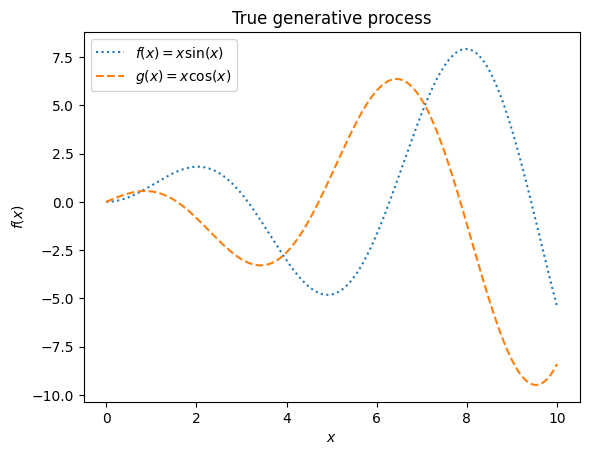

In [12]:
plt.plot(X, y1, label=r"$f(x) = x \sin(x)$", linestyle="dotted")
plt.plot(X, y2, label=r"$g(x) = x \cos(x)$", linestyle="--")
plt.legend()
plt.xlabel("$x$")
plt.ylabel("$f(x)$")
_ = plt.title("True generative process")

In [13]:
rng = np.random.RandomState(1)
training_indices = rng.choice(np.arange(1000), size=6, replace=False)
X_train, y_train = X[training_indices], y[training_indices]

In [14]:
y_train

array([[-4.74492726,  1.80056999],
       [ 7.73514288, -2.68588726],
       [-4.44491693, -0.84500632],
       [-1.90051689, -3.15556034],
       [ 1.5957965 , -1.82251583],
       [ 1.16380401, -9.22618706]])

In [15]:
kernel = 1 * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2))
gaussian_process = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=9)
gaussian_process.fit(X_train, y_train)
gaussian_process.kernel_

5.98**2 * RBF(length_scale=1.7)

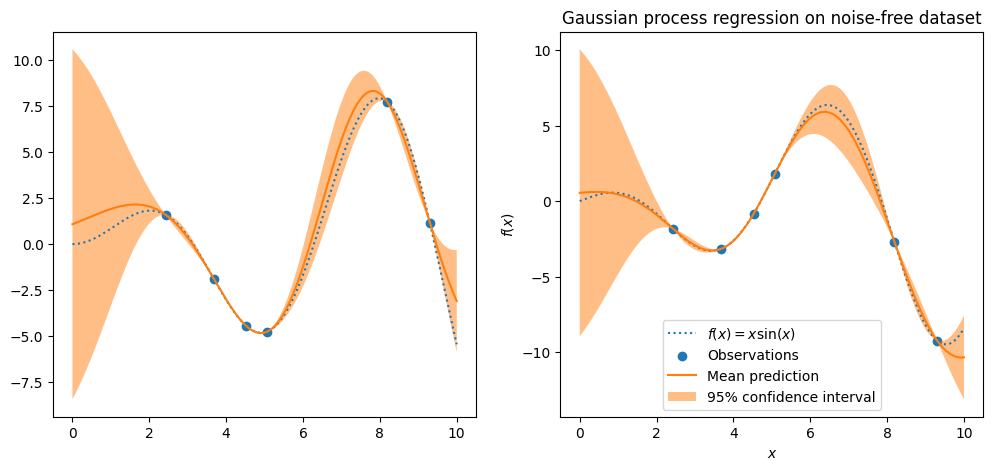

In [16]:
mean_prediction, std_prediction = gaussian_process.predict(X, return_std=True)
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].plot(X, y[:, 0], label=r"$f(x) = x \sin(x)$", linestyle="dotted")
axs[0].scatter(X_train, y_train[:, 0], label="Observations")
axs[0].plot(X, mean_prediction[:, 0], label="Mean prediction")
axs[0].fill_between(
    X.ravel(),
    mean_prediction[:, 0] - 1.96 * std_prediction[:, 0],
    mean_prediction[:, 0] + 1.96 * std_prediction[:, 0],
    alpha=0.5,
    label=r"95% confidence interval",
)

axs[1].plot(X, y[:, 1], label=r"$f(x) = x \sin(x)$", linestyle="dotted")
axs[1].scatter(X_train, y_train[:, 1], label="Observations")
axs[1].plot(X, mean_prediction[:, 1], label="Mean prediction")
axs[1].fill_between(
    X.ravel(),
    mean_prediction[:, 1] - 1.96 * std_prediction[:, 1],
    mean_prediction[:, 1] + 1.96 * std_prediction[:, 1],
    alpha=0.5,
    label=r"95% confidence interval",
)
plt.legend()
plt.xlabel("$x$")
plt.ylabel("$f(x)$")
_ = plt.title("Gaussian process regression on noise-free dataset")

## CMB Dataset

In [ ]:
# Load data
NUM_TRAIN_SAMPLES = 9864
NUM_TEST_SAMPLES = 976
NUM_ELL = 2999

ell = np.arange(2, 3001)
factor = ell*(ell+1)/(2*np.pi)
train_cosmologies = np.loadtxt("../data/train/cosmologies.txt", max_rows=NUM_TRAIN_SAMPLES)
test_cosmologies = np.loadtxt("../data/test/cosmologies.txt", max_rows=NUM_TEST_SAMPLES)
train_cls = np.zeros((NUM_TRAIN_SAMPLES, NUM_ELL))
test_cls  = np.zeros((NUM_TRAIN_SAMPLES, NUM_ELL))

for i in range(1, NUM_TRAIN_SAMPLES+1):
    dl_tt, dl_te, dl_ee = np.loadtxt(f"../data/train/cl_{i}.txt", unpack=True)
    train_cls[i-1] = dl_tt/factor

for i in range(1, NUM_TEST_SAMPLES+1):
    cl_tt, cl_te, cl_ee = np.loadtxt(f"../data/test/cl_{i}.txt", unpack=True)
    test_cls[i-1] = dl_tt/factor


/var/folders/pm/h623358x68n6tdb7xj7s_9qr0000gn/T/ipykernel_1957/960454047.py:8: UserWarning: Input line 1 contained no data and will not be counted towards `max_rows=9864`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.islice`.
Please see the 1.23 release notes for an example on how to do this.  If you wish to ignore this warning, use `warnings.filterwarnings`.  This warning is expected to be removed in the future and is given only once per `loadtxt` call.
  train_cosmologies = np.loadtxt("../data/train/cosmologies.txt", max_rows=NUM_TRAIN_SAMPLES)
/var/folders/pm/h623358x68n6tdb7xj7s_9qr0000gn/T/ipykernel_1957/960454047.py:9: UserWarning: Input line 1 contained no data and will not be counted towards `max_rows=976`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.i

In [41]:
# Thinning training sample
partial_indices = np.random.choice(np.arange(NUM_TRAIN_SAMPLES), size=1000)
train_cosmologies_partial = train_cosmologies[partial_indices]
train_cls_partial         = train_cls[partial_indices]

In [42]:
# Scale by As
As1e10 = np.exp(train_cosmologies_partial[:, 3])
for i, cl in enumerate(train_cls_partial):
    train_cls_partial[i]  = cl/As1e10[i]
train_cosmologies_partial = np.delete(train_cosmologies_partial, 3, axis=1) # No need for As in inputs

# Take the log
train_logcls_partial = np.log(train_cls_partial)

Text(0.5, 1.0, 'Training data')

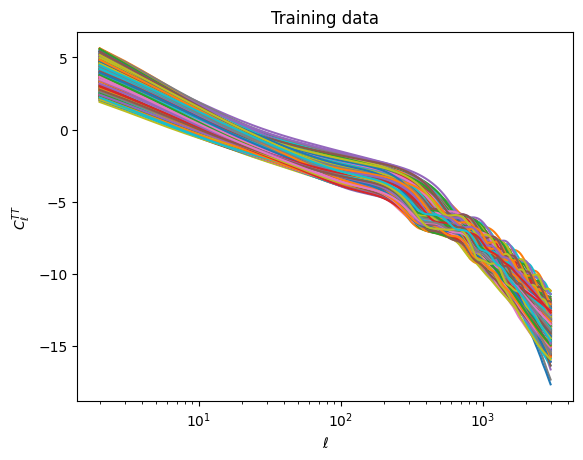

In [43]:
for logcl in train_logcls_partial:
    plt.semilogx(ell, logcl)
plt.xlabel("$\\ell$")
plt.ylabel("$C_\\ell^{TT}$")
plt.title("Training data")

In [60]:
# Scalers for inputs and outputs
scaler_cosmo = StandardScaler()
scaled_cosmos = scaler_cosmo.fit_transform(train_cosmologies_partial)

In [61]:
# PCA
num_pcs = 30
pca = PCA(n_components=30, svd_solver='full')
train_pcs = pca.fit_transform(train_logcls_partial)
scaler_pcs = StandardScaler()
scaled_pcs = scaler_pcs.fit_transform(train_pcs)

In [62]:
models = []
for i in range(num_pcs):
    kernel = ConstantKernel(constant_value=1, constant_value_bounds=(1e-3, 1e3)) * Matern(length_scale=[1.0, 1.0, 1.0, 1.0, 1.0], length_scale_bounds=(1e-2, 1e2), nu=2.5)
    gaussian_process = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=3)

    X_train = scaled_cosmos
    y_train = scaled_pcs[:, i]

    print(f"Training model for pc {i}")
    gaussian_process.fit(X_train, y_train)
    models.append(gaussian_process)

Training model for pc 0


/Users/joao/miniconda3/envs/hackathon/lib/python3.11/site-packages/sklearn/gaussian_process/_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 21 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/Users/joao/miniconda3/envs/hackathon/lib/python3.11/site-packages/sklearn/gaussian_process/_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 24 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/Users/joao/miniconda3/envs/hackathon/lib/python3.11/site-packages/sklearn/gaussian_process/_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 7 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/prep

Training model for pc 1


/Users/joao/miniconda3/envs/hackathon/lib/python3.11/site-packages/sklearn/gaussian_process/_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 18 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


Training model for pc 2


...

Training model for pc 27


/Users/joao/miniconda3/envs/hackathon/lib/python3.11/site-packages/sklearn/gaussian_process/_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 19 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/Users/joao/miniconda3/envs/hackathon/lib/python3.11/site-packages/sklearn/gaussian_process/_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 41 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/Users/joao/miniconda3/envs/hackathon/lib/python3.11/site-packages/sklearn/gaussian_process/_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 0 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/prep

Training model for pc 28


/Users/joao/miniconda3/envs/hackathon/lib/python3.11/site-packages/sklearn/gaussian_process/_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 37 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


Training model for pc 29


In [53]:
def predict(models, x):
    As1e10_input = np.exp(x[3])
    x_input = scaler_cosmo.transform([[x[0], x[1], x[2], x[4], x[5]]])
    scaled_pcs_pred = []
    for i in range(num_pcs):
        scaled_pc_pred = models[i].predict(x_input)
        scaled_pcs_pred.append(scaled_pc_pred[0])
    pred_pcs = scaler_pcs.inverse_transform([scaled_pcs_pred])
    scaled_logcl = pca.inverse_transform(pred_pcs)
    logcl = scaler_logcls.inverse_transform(scaled_logcl)
    return As1e10_input*np.exp(logcl)[0]

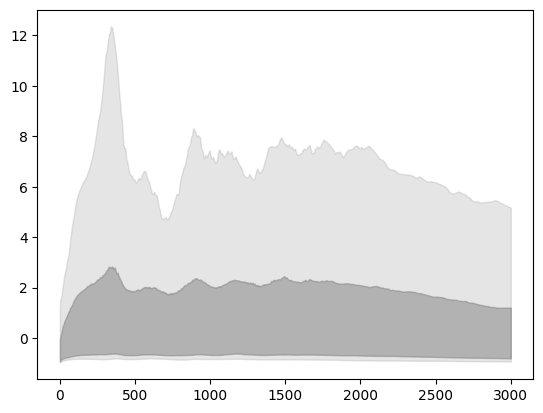

In [54]:
errors = []
for i in range(NUM_TEST_SAMPLES):
    truth = test_cls[i]
    pred = predict(models, test_cosmologies[i])
    err = (pred - truth)/truth
    errors.append(err)
errors = np.array(errors)
lower = np.percentile(errors, 2.5, axis=0)
upper = np.percentile(errors, 97.5, axis=0)
plt.fill_between(ell, lower, upper, alpha=0.2, color="gray")
lower = np.percentile(errors, 50-68//2, axis=0)
upper = np.percentile(errors, 50+68//2, axis=0)
plt.fill_between(ell, lower, upper, alpha=0.5, color="gray")

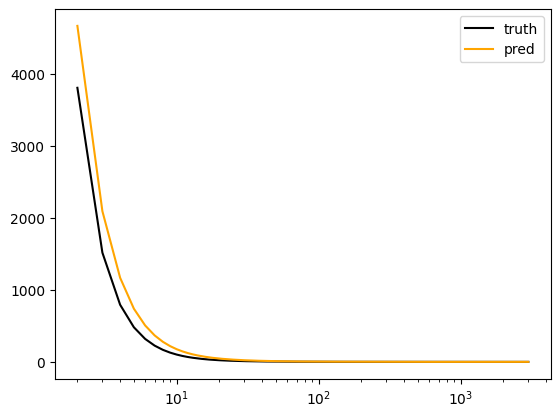

In [59]:
i = 300
truth = test_cls[i]
pred = predict(models, test_cosmologies[i])
plt.semilogx(ell, truth, color="black", label="truth")
plt.semilogx(ell, pred, color="orange", label="pred")
plt.legend()